[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Dropout

Dropout is a component of the transformer architecture — the original paper applies it at three separate points inside every block — and this is the point in the course to introduce it.  It has a longer history than transformers: for a decade it was the default regularizer for neural networks of every kind.  We will define it, implement it, and then spend the second half of the notebook on a question whose answer is less obvious than it looks — when does it actually help?

The idea starts somewhere unlikely: with noise.

Classical generalization theory says that to close the gap between training and test performance we should prefer a *simple* model.  We have already met two notions of simplicity.  One is a small number of dimensions, which is what the monomial-basis experiments in the linear-models notebook were about.  Another is a small parameter norm, which is what weight decay enforces.  Here is a third: **smoothness**.  A good classifier should not change its mind when you jiggle its input.  Add a little noise to the pixels of an image and the predicted label should stay put.

Bishop (1995) made that precise, proving that *training with noise added to the inputs is equivalent to Tikhonov regularization* — the same penalty weight decay applies.  Smoothness and a small parameter norm turned out to be two descriptions of one thing.

> Bishop, C. M. (1995).  Training with noise is equivalent to Tikhonov regularization.  *Neural Computation*, 7(1), 108–116.

Srivastava and colleagues then asked what happens if the noise goes *deeper* — not at the input, but at every hidden layer — and in a particular form.  Rather than adding Gaussian noise to a unit, delete the unit outright, at random, on every minibatch.

> Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014).  Dropout: a simple way to prevent neural networks from overfitting.  *Journal of Machine Learning Research*, 15(56), 1929–1958.

Concretely, with **dropout probability** $p$, each hidden activation $h$ is replaced during training by

$$
h' =
\begin{cases}
    0 & \textrm{with probability } p \\[2pt]
    \dfrac{h}{1-p} & \textrm{otherwise}
\end{cases}
$$

Two things to notice in that definition.  The zeroing is the noise.  The division by $1-p$ is bookkeeping: it makes $E[h'] = h$, so the layer above sees inputs of the same average magnitude whether dropout is on or off.  Without it, turning dropout off at prediction time would hand every subsequent layer inputs roughly $1/(1-p)$ times larger than the ones it was trained on.

In [ ]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import time

import torch
from torch import nn
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

BLUE, GREEN, IO = '#cdddec', '#d0e3d4', '#ededed'
AMBER, TX = '#c0662f', '#333333'

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using {device} device')

Using cpu device


## What dropout does to a network

Applying dropout to a hidden layer, with each unit zeroed independently with probability $p$, leaves a network containing only a subset of the original units.  The picture below shows one such draw.

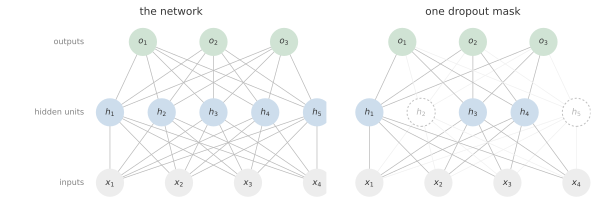

In [ ]:
# the d2l figure, redrawn: a network, and the same network under one mask
def dropout_figure(dropped=(1, 4)):
    """A two-hidden-layer MLP, and the same network under one dropout mask."""
    n_in, n_hid, n_out = 4, 5, 3
    R = 0.30                                   # node radius
    rows = {'x': 0.0, 'h': 1.5, 'o': 3.0}      # vertical position of each layer

    def xs(n, width=4.4):
        return [(i - (n - 1) / 2) * width / max(n - 1, 1) for i in range(n)]

    X, H, O = xs(n_in), xs(n_hid), xs(n_out, 3.0)

    fig, axes = plt.subplots(1, 2, figsize=(8.4, 2.9),
                             gridspec_kw={'width_ratios': [6.6, 5.0],
                                          'wspace': 0.04})
    for panel, (ax, drop) in enumerate(zip(axes, [(), dropped])):
        # edges first, so nodes sit on top of them
        for i, x0 in enumerate(X):
            for j, x1 in enumerate(H):
                live = j not in drop
                ax.plot([x0, x1], [rows['x'], rows['h']], lw=0.7, zorder=1,
                        color='0.72' if live else '#f0f0f0')
        for j, x0 in enumerate(H):
            for k, x1 in enumerate(O):
                live = j not in drop
                ax.plot([x0, x1], [rows['h'], rows['o']], lw=0.7, zorder=1,
                        color='0.72' if live else '#f0f0f0')

        def node(x, y, label, fc, ec='none', ls='-', tc=TX):
            ax.add_patch(plt.Circle((x, y), R, facecolor=fc, edgecolor=ec,
                                    linewidth=1.0, linestyle=ls, zorder=3))
            ax.text(x, y, label, ha='center', va='center', fontsize=8.5,
                    color=tc, zorder=4)

        for i, x in enumerate(X):
            node(x, rows['x'], f'$x_{i+1}$', IO)
        for j, x in enumerate(H):
            if j in drop:
                node(x, rows['h'], f'$h_{j+1}$', 'white', ec='0.75',
                     ls=(0, (2, 2)), tc='0.7')
            else:
                node(x, rows['h'], f'$h_{j+1}$', BLUE)
        for k, x in enumerate(O):
            node(x, rows['o'], f'$o_{k+1}$', GREEN)

        if panel == 0:
            for y, lab in [(rows['x'], 'inputs'), (rows['h'], 'hidden units'),
                           (rows['o'], 'outputs')]:
                ax.text(-2.75, y, lab, ha='right', va='center', fontsize=8,
                        color='0.5')
            ax.set_xlim(-4.2, 2.4)
        else:
            ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-0.45, 3.45)
        ax.set_aspect('equal'); ax.axis('off')

    axes[0].set_title('the network', fontsize=10.5, color=TX)
    axes[1].set_title('one dropout mask', fontsize=10.5, color=TX)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.90, bottom=0.02,
                        wspace=0.04)


dropout_figure()

Because $h_2$ and $h_5$ are zero on this minibatch, the outputs cannot depend on them, and no gradient flows to the weights that feed them.  A *different* subset is dropped on the next minibatch, and the next.  Over training, no output ever gets to rely on any particular hidden unit being present, because it frequently is not.

That is the argument Srivastava and colleagues gave, in their own vocabulary.  They characterized overfitting as **co-adaptation**: a unit learns to be useful only in combination with a specific pattern of other units, a committee that works together and fails together.  Dropout breaks the committees up, because a unit that might vanish at any moment is a poor thing to depend on, and what survives is a set of features that are individually useful.  Whether that is the right explanation is still argued about; the technique outlived the argument.

## Implementing it

To drop out a layer's activations we need one Bernoulli sample per activation, taking value 1 (keep) with probability $1-p$ and 0 (drop) with probability $p$.  The easy way is to draw from $U[0,1]$ and keep the entries whose sample exceeds $p$.

In [ ]:
def dropout_layer(X, p):
    """Zero each entry of X with probability p, rescaling the survivors."""
    assert 0 <= p <= 1
    if p == 1:
        return torch.zeros_like(X)
    mask = (torch.rand_like(X) > p).float()     # 1 = keep, 0 = drop
    return mask * X / (1.0 - p)


X = torch.arange(16, dtype=torch.float32).reshape(2, 8)
torch.manual_seed(0)
for p in (0.0, 0.5, 1.0):
    print(f'p = {p}\n{dropout_layer(X, p)}')

p = 0.0
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
p = 0.5
tensor([[ 0.,  2.,  0.,  0.,  8., 10.,  0., 14.],
        [ 0., 18., 20.,  0.,  0.,  0.,  0., 30.]])
p = 1.0
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


At $p = 0.5$ about half the entries are gone and the survivors have doubled — the rescaling that keeps the layer's expected output where it was.

The original paper did this the other way round: it left the activations untouched during training and multiplied by $1-p$ at prediction time instead.  The two agree in expectation.  Rescaling during training is what every framework does now, `nn.Dropout` included, because it leaves the prediction-time network an ordinary, unmodified one — there is nothing to remember to undo.

## Training and testing behave differently

Dropout is the first component we have written that **behaves differently in training and in testing**.  While training it is random; at test time we want a deterministic prediction, so nothing is dropped and nothing is rescaled.

`nn.Dropout` reads the `self.training` flag that every `nn.Module` carries, and `model.train()` and `model.eval()` are precisely the methods that set that flag throughout a model.  Watch all of it at once:

In [ ]:
torch.manual_seed(0)
layer = nn.Dropout(0.5)
h = torch.arange(1.0, 9.0)
print('h                    ', h.numpy())

layer.train()
print('\ntraining mode -- a new mask every call:')
for _ in range(3):
    print('                     ', layer(h).numpy())

layer.eval()
print('\nevaluation mode -- the identity:')
for _ in range(2):
    print('                     ', layer(h).numpy())

# averaged over many masks, the training-time output matches what evaluation
# mode returns -- which is exactly what dividing by 1 - p buys us
layer.train()
average = torch.stack([layer(h) for _ in range(20_000)]).mean(0)
print('\nmean of 20,000 training-mode passes:', average.round(decimals=2).numpy())

h                     [1. 2. 3. 4. 5. 6. 7. 8.]

training mode -- a new mask every call:
                      [ 0.  0.  6.  0.  0.  0. 14. 16.]
                      [ 0.  4.  6.  8. 10.  0. 14. 16.]
                      [ 2.  4.  0.  0. 10.  0. 14.  0.]

evaluation mode -- the identity:
                      [1. 2. 3. 4. 5. 6. 7. 8.]
                      [1. 2. 3. 4. 5. 6. 7. 8.]

mean of 20,000 training-mode passes: [0.99 1.99 3.01 3.97 5.06 5.99 7.04 8.02]


The last block checks the rescaling: averaged over enough masks, the training-time activations reproduce the evaluation-time ones exactly, which is what dividing by $1-p$ was for.  It is worth confirming rather than taking on faith, because everything above this layer depends on it — a layer that quietly changed the scale of its output between training and testing would hand the layers above it inputs of a magnitude they were never trained on.

The practical consequence is that `model.eval()` is not optional.  Evaluate a dropout model without it and you are scoring a randomly thinned network rather than the model — your validation numbers come out noisy and pessimistic, and the mistake is invisible unless you look for it.  (`torch.no_grad()` is a *different* thing, and does not set the flag; a model must be put in `eval()` mode explicitly.)  We will put a number on that cost at the end.

## When does dropout help?

Now the question that matters, and it needs to be asked carefully, because the honest answer is more interesting than "dropout improves accuracy".

Dropout is a *regularizer*: it trades training fit for generalization.  That trade can only pay off if there is something to buy — if the model is fitting the training set much better than the test set.  A model that has not overfit has no excess variance to remove, and a regularizer applied to it can only take away capacity it was using.  So the question is not "does dropout help?" but "at what data-to-capacity ratio does dropout help?"

We can answer that directly.  Hold the architecture fixed — a two-hidden-layer MLP, 512 units each — and vary the one quantity the argument says should matter: the number of training examples.  Fashion-MNIST gives us 60,000, and we can train on any subset of them.

In [ ]:
# Fashion-MNIST, held in memory: the MLP is small enough that the DataLoader
# machinery would cost more than the arithmetic.
train_set = datasets.FashionMNIST('../data', train=True, download=True,
                                  transform=transforms.ToTensor())
val_set = datasets.FashionMNIST('../data', train=False, download=True,
                                transform=transforms.ToTensor())

train_X = (train_set.data.float() / 255).reshape(-1, 784).to(device)
train_y = train_set.targets.to(device)
val_X = (val_set.data.float() / 255).reshape(-1, 784).to(device)
val_y = val_set.targets.to(device)
print(f'{len(train_X):,} training and {len(val_X):,} validation images, '
      f'{train_X.shape[1]} pixels each')

60,000 training and 10,000 validation images, 784 pixels each


In [ ]:
def mlp(dropout, num_hiddens=512):
    """Two hidden layers, with dropout after each activation."""
    return nn.Sequential(
        nn.Linear(784, num_hiddens), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(num_hiddens, num_hiddens), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(num_hiddens, 10))


def accuracy(logits, y):
    """Fraction of correct predictions."""
    return (logits.argmax(dim=1) == y).float().mean()


def train(n_train, dropout, epochs, lr=1e-3, batch_size=128, seed=0):
    """Train on the first `n_train` images; return the model and its history."""
    torch.manual_seed(seed)
    X, y = train_X[:n_train], train_y[:n_train]
    model = mlp(dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = []
    for epoch in range(epochs):
        model.train()
        for i in torch.randperm(n_train, device=device).split(batch_size):
            optimizer.zero_grad()
            loss_fn(model(X[i]), y[i]).backward()
            optimizer.step()
        model.eval()                      # <- without this we would be scoring
        with torch.no_grad():             #    a randomly thinned net
            logits = model(val_X)
            history.append((loss_fn(model(X[:5000]), y[:5000]).item(),
                            loss_fn(logits, val_y).item(),
                            accuracy(logits, val_y).item()))
    return model, history

In [ ]:
# Fewer examples need more passes to converge, so the epoch budget scales with n.
SIZES = [(1_000, 100), (5_000, 60), (60_000, 15)]
RATES = (0.0, 0.5)

models, history = {}, {}
t0 = time.time()
for n_train, epochs in SIZES:
    for p in RATES:
        models[n_train, p], history[n_train, p] = train(n_train, p, epochs)
        print(f'n = {n_train:6,d}  dropout {p}  done  ({time.time() - t0:4.0f}s)')
print(f'\ntotal {(time.time() - t0) / 60:.1f} min')

n =  1,000  dropout 0.0  done  (  77s)
n =  1,000  dropout 0.5  done  ( 139s)
n =  5,000  dropout 0.0  done  ( 278s)
n =  5,000  dropout 0.5  done  ( 373s)
n = 60,000  dropout 0.0  done  ( 425s)
n = 60,000  dropout 0.5  done  ( 505s)

total 8.4 min


In [ ]:
def report(h):
    """train loss, best validation accuracy, and validation loss best -> final."""
    return h[-1][0], max(x[2] for x in h) * 100, min(x[1] for x in h), h[-1][1]


print(f'{"":>8}  {"":>10}  {"train":>7}  {"best val":>9}  {"val loss":>18}')
print(f'{"n":>8}  {"dropout":>10}  {"loss":>7}  {"accuracy":>9}  '
      f'{"best":>8} {"final":>9}')
print('-' * 62)
for n_train, _ in SIZES:
    for p in RATES:
        tr, acc, lo_best, lo_final = report(history[n_train, p])
        print(f'{n_train:8,d}  {p:>10}  {tr:7.3f}  {acc:8.2f}%  '
              f'{lo_best:8.3f} {lo_final:9.3f}')
    print()

                        train   best val            val loss
       n     dropout     loss   accuracy      best     final
--------------------------------------------------------------
   1,000         0.0    0.001     80.88%     0.614     1.265
   1,000         0.5    0.030     81.03%     0.591     1.001

   5,000         0.0    0.040     84.92%     0.463     0.703
   5,000         0.5    0.143     85.34%     0.454     0.511

  60,000         0.0    0.181     89.00%     0.324     0.346
  60,000         0.5    0.243     88.28%     0.326     0.328



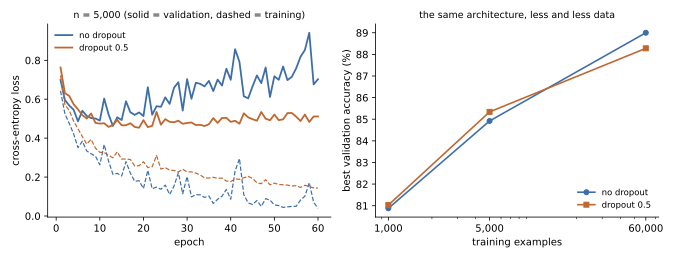

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.4, 3.6))

# left: the loss curves at the middle training-set size
N_SHOW = 5_000
for p, color in [(0.0, '#3d6ea8'), (0.5, AMBER)]:
    h = history[N_SHOW, p]
    epochs = range(1, len(h) + 1)
    ax1.plot(epochs, [x[0] for x in h], color=color, lw=1.2, ls='--')
    ax1.plot(epochs, [x[1] for x in h], color=color, lw=1.8,
             label=f'dropout {p}' if p else 'no dropout')
ax1.set_xlabel('epoch'); ax1.set_ylabel('cross-entropy loss')
ax1.set_title(f'n = {N_SHOW:,}   (solid = validation, dashed = training)',
              fontsize=9.5)
ax1.legend(frameon=False, fontsize=8.5)
ax1.spines[['top', 'right']].set_visible(False)

# right: the best accuracy each setting reaches, against training-set size
ns = [n for n, _ in SIZES]
for p, color, marker in [(0.0, '#3d6ea8', 'o'), (0.5, AMBER, 's')]:
    best = [max(x[2] for x in history[n, p]) * 100 for n in ns]
    ax2.plot(ns, best, marker=marker, color=color, markersize=5, lw=1.6,
             label=f'dropout {p}' if p else 'no dropout')
ax2.set_xscale('log')
ax2.set_xticks(ns); ax2.set_xticklabels([f'{n:,}' for n in ns])
ax2.set_xlabel('training examples'); ax2.set_ylabel('best validation accuracy (%)')
ax2.set_title('the same architecture, less and less data', fontsize=9.5)
ax2.legend(frameon=False, fontsize=8.5, loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)

fig.tight_layout();

Read the table one column at a time; each says something different.

**The training loss** tells you which regime you are in.  At 1,000 and 5,000 examples the undropped model drives it essentially to zero: it has memorized its training set outright.  At 60,000 it cannot — the same 512-512 network, given sixty times the data, no longer has the capacity to memorize.  Overfitting appears, and then disappears, without our touching the architecture.

**The validation loss** is where dropout's effect is unmistakable, and the left-hand plot shows why.  Without dropout the curve reaches its minimum early and then climbs steadily — the model does not merely stop improving, it gets *worse*, growing more and more confident about answers that are increasingly wrong.  With dropout the curve settles near its minimum and stays there.  Dropout does not just lower the loss; it removes the penalty for training too long.

**The accuracy** is the sober column.  Dropout buys something like half a point where it helps at all, and at the full 60,000 examples it makes things slightly *worse* — the network was barely overfitting, so the regularizer cost more capacity than it saved variance.  That reversal is not a flaw in the experiment.  It is the answer to the question we asked: dropout is a response to a data-to-capacity ratio, and applying it outside that regime is not free.

Which leaves an honest summary worth carrying around.  Dropout mostly buys *robustness*: it makes a training run forgiving, so that a model slightly too large, or trained for too many epochs, does not fall apart.  It buys a modest amount of peak accuracy on top.  That is exactly why it became a default for models trained on limited data — and also why the largest language models often set it to zero, since a model that sees each token roughly once cannot overfit in the first place.

One caution before you draw conclusions from your own runs: the accuracy differences here are a few tenths of a point, which is the same order as the run-to-run variation from a different random seed.  The validation-loss difference is not — it is large and it reproduces.  When an effect is small, one run is an anecdote (exercise 1).

Finally, the cost of the mistake we have been guarding against all along.  Here is the same trained model scored with and without `model.eval()`:

In [ ]:
model = models[5_000, 0.5]

model.eval()
with torch.no_grad():
    print(f'eval()  mode: {accuracy(model(val_X), val_y) * 100:.2f}%   '
          '(deterministic -- this is the model)')

model.train()
with torch.no_grad():
    scores = [accuracy(model(val_X), val_y).item() * 100 for _ in range(5)]
print('train() mode:', ' '.join(f'{s:.2f}%' for s in scores),
      '\n              (a different random thinning each time)')

eval()  mode: 84.87%   (deterministic -- this is the model)
train() mode: 82.90% 82.78% 83.16% 82.67% 82.64% 
              (a different random thinning each time)


Two points of accuracy, thrown away by one missing line — and nothing about the output looks wrong.  This is among the most common bugs in deep learning code, and it is why every training loop in these notebooks calls `model.train()` and `model.eval()` explicitly even when nothing in the model depends on the flag yet.  Later, batch normalization will make the same mistake far more expensive.

## Dropout in a transformer

Which brings us back to why this notebook sits in the attention module.  The transformer we are about to build applies dropout in three places, all of them instances of what we just did:

* **On each sublayer's output**, immediately before it is added to the residual stream — so the model cannot come to depend on any one sublayer's contribution being present.  Notice what is *not* dropped: the residual path itself, which has to stay intact.
* **On the sum of the token embeddings and the positional encoding**, at the very bottom of the stack.
* **On the attention weights themselves**, after the softmax — dropping connections between positions rather than units, so no query can rely on always being able to see a particular key.

The rate is usually small, 0.1 rather than the 0.5 we used here, because a transformer block has many more sublayers to inject noise into than our two-layer MLP.  When you meet the `dropout` argument in the next notebook, it is this, applied at those three points.

## Summary

* Dropout injects noise into training by **zeroing each hidden activation with probability $p$** and dividing the survivors by $1-p$.  The rescaling keeps the layer's expected output unchanged, which we confirmed numerically.  The original paper rescaled at prediction time instead; doing it during training leaves the prediction-time network unmodified.
* It is the first layer we have written that **behaves differently in training and in testing**.  `model.train()` and `model.eval()` set the flag that switches between them; forgetting `eval()` scores a randomly thinned network and quietly costs accuracy.
* Dropout is a regularizer, so it only pays where there is overfitting to remove.  Holding the architecture fixed and shrinking the training set makes its benefit appear; restoring the full training set makes it disappear and then reverse.
* Its clearest and most reliable effect is on the **validation loss**, which stops climbing.  The accuracy gain is real but modest, and comparable in size to seed-to-seed noise — measure it accordingly.

## Exercises

1. **One run is an anecdote.**  Rerun the $n = 5{,}000$ comparison with `seed` set to 0, 1 and 2.  Report the mean and spread of the best validation accuracy, and of the final validation loss.  Which of the two supports a confident claim, and which does not?
2. **The rate.**  Sweep `dropout` over $\{0, 0.1, 0.25, 0.5, 0.8\}$ at $n = 5{,}000$.  Where is the optimum, and what does $p = 0.8$ do to the *training* loss?  Explain the shape of the curve in terms of the bias–variance trade-off.
3. **Dropout against weight decay.**  Bishop's result connects noise injection to $\ell_2$ regularization, so the two should be doing related work.  Replace dropout with `Adam(..., weight_decay=1e-4)` at $n = 5{,}000$ and compare all three columns of the table.  Then try both at once: is the benefit additive?
4. **Capacity, not just data.**  Keep the full 60,000 examples but widen the hidden layers to 2,048 units.  Does dropout start helping again?  Relate your answer to the sweep — which knob were you really turning?
5. **Near the input.**  Add a `nn.Dropout` on the pixels themselves, before the first linear layer.  Convention says to use a lower rate there than in the hidden layers; try 0.2 and 0.5 and explain what goes wrong at the higher rate.
6. **Your implementation, in the model.**  Write a `Module` that calls the `dropout_layer` from this notebook, guarded by `self.training`, and substitute it for `nn.Dropout`.  Reproduce one row of the table to confirm the two agree.
7. **How bad is the missing `eval()`?**  In training mode, average the model's *logits* over $k$ forward passes before taking the argmax, for increasing $k$.  How close does the accuracy get to the `eval()` number, and does it ever match it exactly?  Explain, in terms of where the nonlinearities sit, why averaging the outputs of many thinned networks is not the same thing as running the unthinned one — even though the check earlier in this notebook came out exact for a single layer.
8. **The size of the noise.**  Show that dropout gives $E[h'] = h$ and $\textrm{Var}[h'] = h^2 p / (1 - p)$.  Plot that variance against $p$, and use it to account for the training loss you measured in exercise 2 at $p = 0.8$.  Where does the injected noise start to overwhelm the signal?